<a href="https://colab.research.google.com/github/sathishkumar19/Scaler-DSML-Course/blob/main/docs/Databases/Projects/cineflix_store/cineflix_store_sql_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## CineFlix Data Analysis using SQL


### Importing the Data for SQL Analysis

In [5]:
from google.colab import auth
from google.cloud import bigquery
import os
import zipfile

In [7]:
# ✅ Authenticate with your Google account
auth.authenticate_user()

# ✅ Ask for project ID
project_id = input("Please enter your Google Cloud Project ID:")

Please enter your Google Cloud Project ID:sathish-scalar-projects


In [8]:
# ✅ Upload your ZIP
from google.colab import files
uploaded = files.upload()

In [14]:
# ✅ Unzip uploaded file
import shutil
zip_file_name = next(iter(uploaded))
base_extract_path = "/content/bq_dataset_files"
with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
    zip_ref.extractall(base_extract_path)

In [15]:
# ✅ Dataset mapping (folder names inside your ZIP)
dataset_mapping = {
    "cineflix_store": "cineflix-store",
 # for summer_olympics.csv in root
}

In [16]:

# ✅ Create datasets and load CSVs
client = bigquery.Client(project=project_id)

for dataset_id, subfolder in dataset_mapping.items():
    dataset_ref = bigquery.Dataset(f"{project_id}.{dataset_id}")
    try:
        client.get_dataset(dataset_ref)
        print(f"✅ Dataset already exists: {dataset_id}")
    except Exception:
        client.create_dataset(dataset_ref)
        print(f"🆕 Created dataset: {dataset_id}")

    folder_path = os.path.join(base_extract_path, "BigQuery-Dataset", subfolder)
    for file in os.listdir(folder_path):
        if file.endswith(".csv"):
            table_id = file.replace(".csv", "")
            file_path = os.path.join(folder_path, file)
            table_ref = f"{project_id}.{dataset_id}.{table_id}"

            job_config = bigquery.LoadJobConfig(
                source_format=bigquery.SourceFormat.CSV,
                skip_leading_rows=1,
                autodetect=True
            )

            with open(file_path, "rb") as source_file:
                job = client.load_table_from_file(source_file, table_ref, job_config=job_config)
            job.result()
            print(f"📥 Uploaded: {file} → {table_ref}")

print("✅ All CSV files uploaded to BigQuery.")

🆕 Created dataset: cineflix_store


FileNotFoundError: [Errno 2] No such file or directory: '/content/bq_dataset_files/BigQuery-Dataset/cineflix-store'

In [9]:
# ✅ Unzip uploaded file
import shutil
zip_file_name = next(iter(uploaded))
base_extract_path = "/content/bq_dataset_files"

# Extract to base path directly instead of a subdirectory
with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
    zip_ref.extractall(base_extract_path)

# ✅ Dataset mapping (folder names inside your ZIP)
dataset_mapping = {
    "cineflix_store": "", # Assuming the CSV files are directly inside the unzipped folder. Adjust if needed.
 # for summer_olympics.csv in root
}


# ✅ Create datasets and load CSVs
client = bigquery.Client(project=project_id)

for dataset_id, subfolder in dataset_mapping.items():
    dataset_ref = bigquery.Dataset(f"{project_id}.{dataset_id}")
    try:
        client.get_dataset(dataset_ref)
        print(f"✅ Dataset already exists: {dataset_id}")
    except Exception:
        client.create_dataset(dataset_ref)
        print(f"🆕 Created dataset: {dataset_id}")

    # folder path adjustment to reflect changes in extraction
    folder_path = os.path.join(base_extract_path, subfolder) # The CSV files should be present directly inside this folder
    for file in os.listdir(folder_path):
        if file.endswith(".csv"):
            table_id = file.replace(".csv", "")
            file_path = os.path.join(folder_path, file)
            table_ref = f"{project_id}.{dataset_id}.{table_id}"

            job_config = bigquery.LoadJobConfig(
                source_format=bigquery.SourceFormat.CSV,
                skip_leading_rows=1,
                autodetect=True
            )

            with open(file_path, "rb") as source_file:
                job = client.load_table_from_file(source_file, table_ref, job_config=job_config)
            job.result()
            print(f"📥 Uploaded: {file} → {table_ref}")

print("✅ All CSV files uploaded to BigQuery.")

StopIteration: 

ER Diagram for the Cineflix Dataset


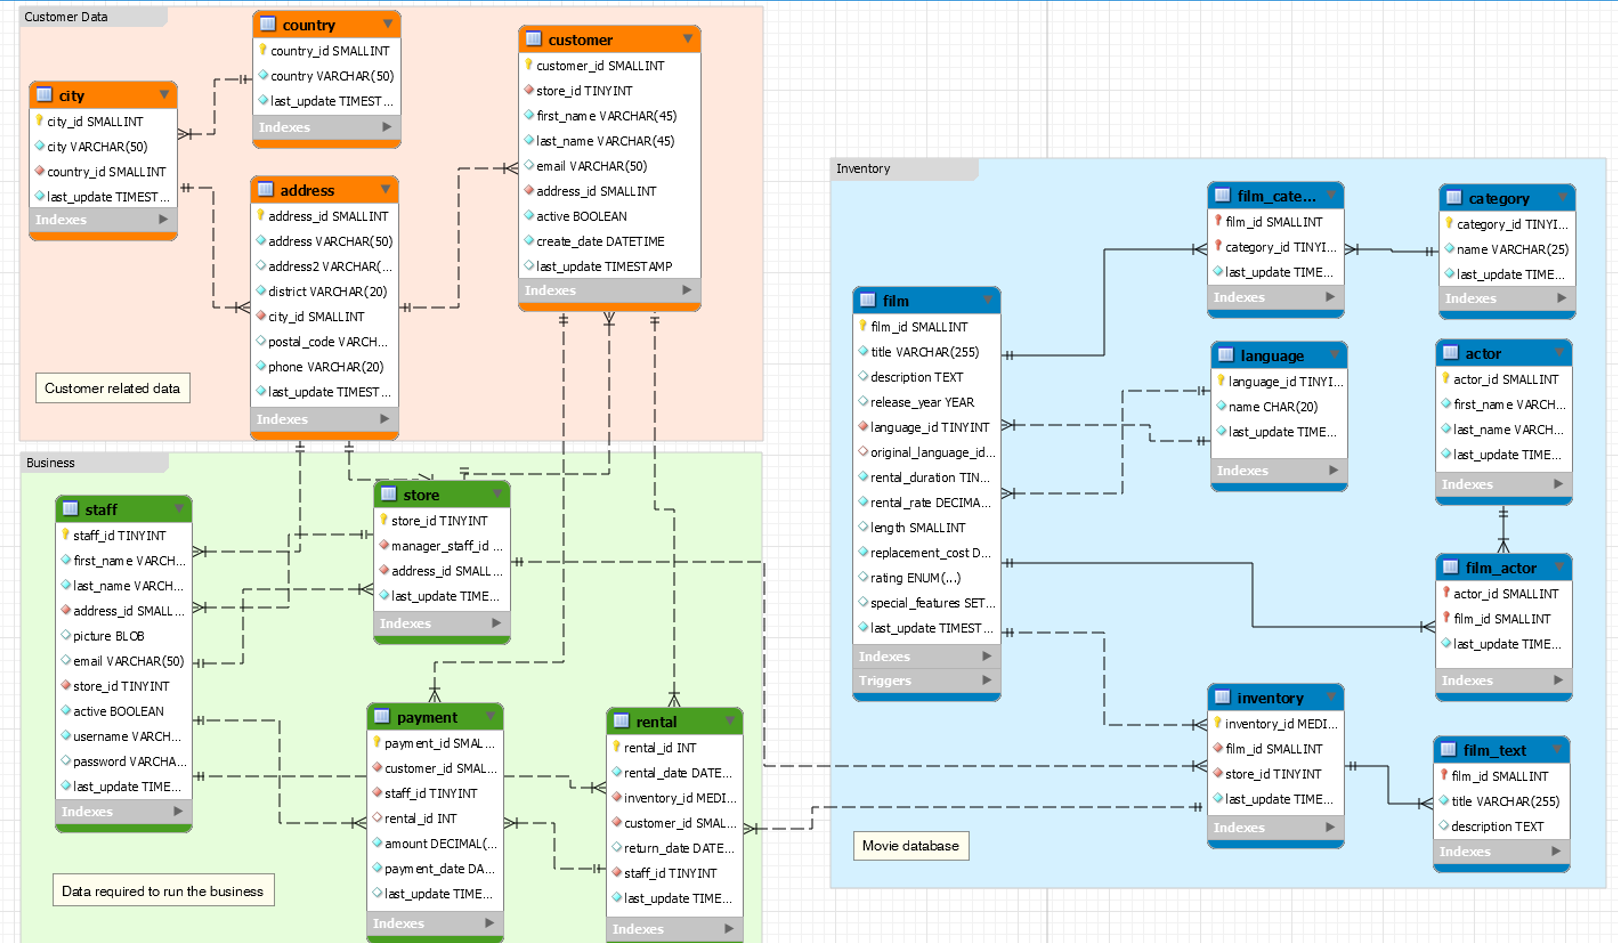

In [18]:
from google.cloud import bigquery
from tabulate import tabulate

In [11]:
# Construct a BigQuery client object.
client = bigquery.Client(project='sathish-scaler-projects') # Assuming you have 'project_id' from before

**Validate the Connection**

In [19]:
# Construct a SQL query.
query = """
    SELECT *
    FROM `sathish-scaler-projects.cineflix_store.actor`  # Replace with your actual dataset and table names
"""
# Execute the query.
query_job = client.query(query)

# Get the results.
results = query_job.result()

# Convert results to pandas DataFrame
df = results.to_dataframe()

# Display DataFrame as a nicely formatted table using tabulate
print(tabulate(df, headers='keys', tablefmt='psql'))

+-----+------------+--------------+--------------+---------------------------+
|     |   actor_id | first_name   | last_name    | last_update               |
|-----+------------+--------------+--------------+---------------------------|
|   0 |         58 | CHRISTIAN    | AKROYD       | 2006-02-15 04:34:33+00:00 |
|   1 |         92 | KIRSTEN      | AKROYD       | 2006-02-15 04:34:33+00:00 |
|   2 |        182 | DEBBIE       | AKROYD       | 2006-02-15 04:34:33+00:00 |
|   3 |        118 | CUBA         | ALLEN        | 2006-02-15 04:34:33+00:00 |
|   4 |        145 | KIM          | ALLEN        | 2006-02-15 04:34:33+00:00 |
|   5 |        194 | MERYL        | ALLEN        | 2006-02-15 04:34:33+00:00 |
|   6 |         76 | ANGELINA     | ASTAIRE      | 2006-02-15 04:34:33+00:00 |
|   7 |        112 | RUSSELL      | BACALL       | 2006-02-15 04:34:33+00:00 |
|   8 |         67 | JESSICA      | BAILEY       | 2006-02-15 04:34:33+00:00 |
|   9 |        190 | AUDREY       | BAILEY       | 2

In [43]:
# Assuming this is within a larger Python script using a database connector
# Example using sqlite3:
import sqlite3
conn = sqlite3.connect('sathish-scaler-projects.cineflix_store.actor')
cursor = conn.cursor()


In [20]:
query = """
SELECT
  c.name as genre,
  count(*) as total_rental
FROM `sathish-scaler-projects.cineflix_store.rental` r
LEFT JOIN `sathish-scaler-projects.cineflix_store.inventory` i
  ON r.inventory_id = i.inventory_id
LEFT JOIN `sathish-scaler-projects.cineflix_store.film_category` fc
  ON i.film_id = fc.film_id
LEFT JOIN `sathish-scaler-projects.cineflix_store.category` c
  on fc.category_id = c.category_id
GROUP BY genre
ORDER by total_rental desc
"""
# Execute the query.
query_job = client.query(query)

# Get the results.
results = query_job.result()

# Convert results to pandas DataFrame
df = results.to_dataframe()

# Display DataFrame as a nicely formatted table using tabulate
print(tabulate(df, headers='keys', tablefmt='psql'))

+----+-------------+----------------+
|    | genre       |   total_rental |
|----+-------------+----------------|
|  0 | Sports      |           1179 |
|  1 | Animation   |           1166 |
|  2 | Action      |           1112 |
|  3 | Sci-Fi      |           1101 |
|  4 | Family      |           1096 |
|  5 | Drama       |           1060 |
|  6 | Documentary |           1050 |
|  7 | Foreign     |           1033 |
|  8 | Games       |            969 |
|  9 | Children    |            945 |
| 10 | Comedy      |            941 |
| 11 | New         |            940 |
| 12 | Classics    |            939 |
| 13 | Horror      |            846 |
| 14 | Travel      |            837 |
| 15 | Music       |            830 |
+----+-------------+----------------+
